# Correspondence Analysis (CA) – Dataset 2

CA is a dimensionality reduction technique for categorical data.

It helps visualize relationships between categories.

In [1]:
import pandas as pd
import prince
import matplotlib.pyplot as plt

df = pd.read_csv("../data/gym_dataset.csv")

In [2]:
cat_df = df[["Workout_Type", "Experience_Level"]].dropna()

In [3]:
contingency = pd.crosstab(
    cat_df["Workout_Type"],
    cat_df["Experience_Level"]
)

display(contingency)

Experience_Level,1,2,3
Workout_Type,,,
Cardio,109,102,44
HIIT,85,87,49
Strength,97,116,45
Yoga,85,101,53


In [4]:
ca = prince.CA(n_components=2, random_state=42)

ca = ca.fit(contingency)

In [5]:
row_coords = ca.row_coordinates(contingency)
col_coords = ca.column_coordinates(contingency)

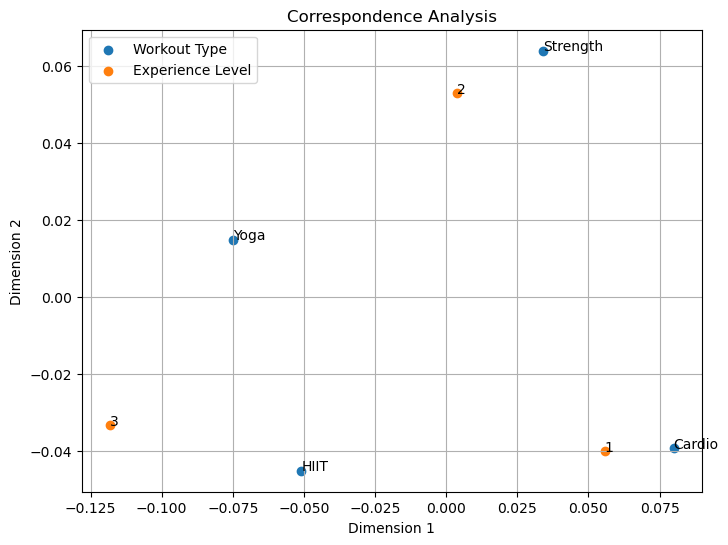

In [6]:
plt.figure(figsize=(8,6))

plt.scatter(row_coords[0], row_coords[1], label="Workout Type")

for i, txt in enumerate(contingency.index):
    plt.text(row_coords.iloc[i, 0], row_coords.iloc[i, 1], txt)

plt.scatter(col_coords[0], col_coords[1], label="Experience Level")

for i, txt in enumerate(contingency.columns):
    plt.text(col_coords.iloc[i, 0], col_coords.iloc[i, 1], str(txt))

plt.title("Correspondence Analysis")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend()

plt.grid()
plt.show()

## Interpretation

Points that are close together are associated.

For example:
- If a workout type is close to a certain experience level, it suggests a relationship.

This helps identify patterns in categorical data.